# Professional NLP Pipeline: Intent Classification

**Abstract**: This notebook outlines a production-grade Natural Language Processing (NLP) pipeline for intent classification. We process conversational data, apply robust feature engineering via Sublinear TF-IDF, and train a highly calibrated Logistic Regression classifier. 

### Pipeline Stages:
1. **Configuration & Reproducibility**: Setting up global states and paths.
2. **Data Ingestion & EDA**: Validating data and analyzing distributions.
3. **Text Preprocessing**: Applying domain-aware normalization.
4. **Label Encoding & Feature Engineering**: Vectorization strategies.
5. **Model Training**: Fitting an optimized linear classifier.
6. **Evaluation & Error Analysis**: Precision/Recall matrices and Visualizations.
7. **Artifact Serialization**: Exporting models for sub-millisecond inference in production.

--- 
### 1. Configuration & Reproducibility
Professional workflows require logging for observability and fixed random seeds to ensure our experiments are reproducible.

In [1]:
import random
import numpy as np
import logging
from pathlib import Path

# Configure standard logging rather than using basic print() statements
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set deterministic seeds for experiment reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Define global configuration dictionary/class
class Config:
    DATA_DIR = Path("CampusFAQ-50K-v1.0/data")
    MODELS_DIR = Path("models")
    REPORTS_DIR = Path("reports")
    
    # Model Hyperparameters
    NGRAM_RANGE = (1, 2)
    MIN_DF = 3
    C_PARAM = 2.5

# Ensure output directories exist
Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
Config.REPORTS_DIR.mkdir(parents=True, exist_ok=True)
logger.info("Project configuration and random states initialized.")

2026-10-04 17:30:29,291 - INFO - Project configuration and random states initialized.


--- 
### 2. Data Ingestion & Validation
We load our datasets using `pandas` and perform initial integrity checks, such as handling null values.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

logger.info("Loading CampusFAQ-50K dataset...")
df = pd.read_csv(Config.DATA_DIR / "campusfaq_50k_v1.0.csv")

# Defensive programming: Ensure no null values break our pipeline down the line
df['query'] = df['query'].fillna("").astype(str)

# Split the dataset 80/20 for training and testing, maintaining intent balance
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['intent'])

logger.info(f"Ingested {len(train_df):,} training and {len(test_df):,} testing samples.")
display(train_df.head())

2026-10-04 17:30:33,993 - INFO - Loading CampusFAQ-50K dataset...


2026-10-04 17:30:34,523 - INFO - Ingested 40,000 training and 10,000 testing samples.


,id,query,intent,response,document_id,document_version,evidence,entities,answerable,difficulty,split,source_authority,provenance
43500,campusfaq50k_036571,Tell me about progression requirements.,promotion_rules,Promotion in the DEMO_ONLY_SYNTHETIC system is...,DOC-ACAD-REG,2026-27-demo,"[{""chunk_id"": ""DOC-ACAD-REG-PR-1"", ""quote"": ""T...",{},True,hard,val,DEMO_ONLY_SYNTHETIC,Deterministically generated from the bundled s...
1782,campusfaq50k_045925,Where can I find the CSE curriculum?,document_location,The DEMO_ONLY CSE curriculum information is in...,DOC-CSE-CURR,2026-27-demo,"[{""chunk_id"": ""DOC-CSE-CURR-DOCLOC-1"", ""quote""...",{},True,easy,train,DEMO_ONLY_SYNTHETIC,Deterministically generated from the bundled s...
47607,campusfaq50k_043171,Where can I find student service information?,student_services,The DEMO_ONLY_SYNTHETIC Student Services Handb...,DOC-STUDENT,2026-27-demo,"[{""chunk_id"": ""DOC-STUDENT-SERV-1"", ""quote"": ""...",{},True,hard,test,DEMO_ONLY_SYNTHETIC,Deterministically generated from the bundled s...
17377,campusfaq50k_003890,What is the course code for Computer Networks?,course_code_lookup,The course code for Computer Networks is CSE301.,DOC-CSE-CURR,2026-27-demo,"[{""chunk_id"": ""DOC-CSE-CURR-CODE-CSE301"", ""quo...","{""course_code"": ""CSE301"", ""course_name"": ""Comp...",True,hard,train,DEMO_ONLY_SYNTHETIC,Deterministically generated from the bundled s...
44202,campusfaq50k_020703,Tell me about elective courses.,elective_information,The DEMO_ONLY_SYNTHETIC Mechanical Engineering...,DOC-ME-CURR,2026-27-demo,"[{""chunk_id"": ""DOC-ME-CURR-ELEC-ME"", ""quote"": ...","{""department"": ""ME""}",True,easy,val,DEMO_ONLY_SYNTHETIC,Deterministically generated from the bundled s...


--- 
### 3. Exploratory Data Analysis (EDA)
Before training, we should inspect the balance of our classes to determine if techniques like class-weighting or stratified sampling are necessary.

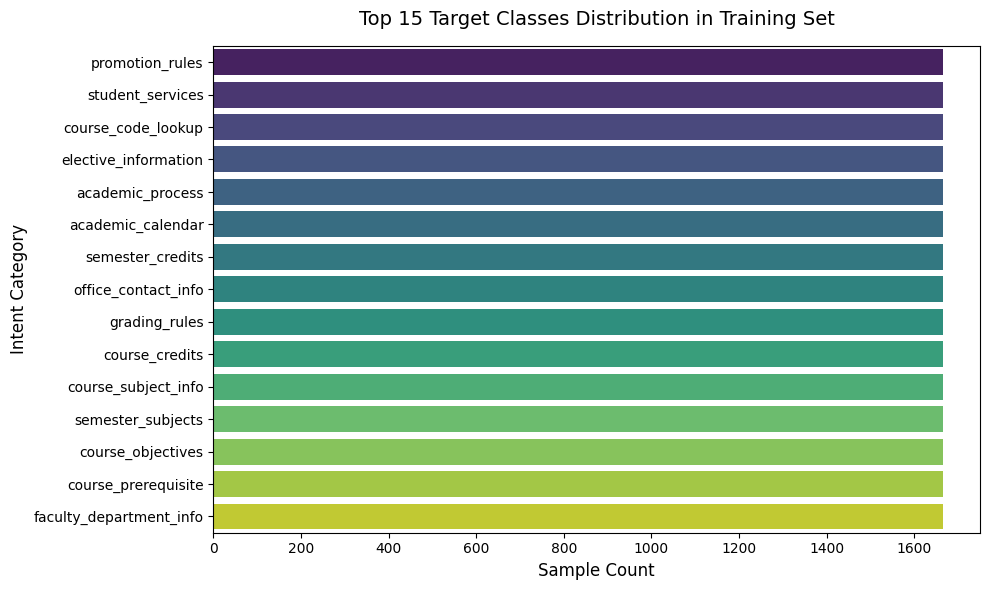

2026-10-04 17:30:36,229 - INFO - Total unique target classes: 24


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress specific seaborn warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, y='intent', order=train_df['intent'].value_counts().index[:15], palette='viridis')
plt.title('Top 15 Target Classes Distribution in Training Set', fontsize=14, pad=15)
plt.xlabel('Sample Count', fontsize=12)
plt.ylabel('Intent Category', fontsize=12)
plt.tight_layout()
plt.show()

logger.info(f"Total unique target classes: {train_df['intent'].nunique()}")

--- 
### 4. Domain-Aware Text Preprocessing
We import our custom backend preprocessor to clean out HTML, standardizing casing, and stripping unnecessary whitespace.

In [4]:
import sys
# Ensure local backend packages can be resolved
sys.path.insert(0, ".")
from backend.nlp.preprocessing import preprocess_query

logger.info("Applying text normalization function to corpora...")

X_train_raw = train_df['query'].tolist()
X_test_raw = test_df['query'].tolist()

X_train = [preprocess_query(q) for q in X_train_raw]
X_test = [preprocess_query(q) for q in X_test_raw]

logger.info(f"Raw Sample:        {X_train_raw[0]}")
logger.info(f"Normalized Sample: {X_train[0]}")

2026-10-04 17:30:36,939 - INFO - Applying text normalization function to corpora...


2026-10-04 17:30:41,065 - INFO - Raw Sample:        Tell me about progression requirements.


2026-10-04 17:30:41,066 - INFO - Normalized Sample: tell me about progression requirement


--- 
### 5. Target Label Encoding
Machine learning estimators expect numeric targets. We fit a robust LabelEncoder to serialize textual target classes into matrix-compatible formats.

In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df['intent'].astype(str))
y_test = label_encoder.transform(test_df['intent'].astype(str))

logger.info(f"Successfully encoded {len(label_encoder.classes_)} categorical targets.")

2026-10-04 17:30:41,076 - INFO - Successfully encoded 24 categorical targets.


--- 
### 6. Feature Engineering (TF-IDF)
We extract sublinear Term Frequency-Inverse Document Frequency features, generating sparse matrices representing uni-grams and bi-grams.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

logger.info("Fitting TF-IDF Vectorizer Space...")
vectorizer = TfidfVectorizer(
    ngram_range=Config.NGRAM_RANGE,
    min_df=Config.MIN_DF,
    max_df=0.85,
    sublinear_tf=True
)

# Fit vocabulary on train, then transform train and test
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

logger.info(f"Constructed Feature Matrix Shape: {X_train_vec.shape}")

2026-10-04 17:30:41,082 - INFO - Fitting TF-IDF Vectorizer Space...


2026-10-04 17:30:41,636 - INFO - Constructed Feature Matrix Shape: (40000, 844)


--- 
### 7. Model Architecture & Training
We use `LogisticRegression` with the `lbfgs` solver, an industrial standard for text categorization due to its speed, low variance, and strong generalizability on high-dimensional sparse data.

In [7]:
from sklearn.linear_model import LogisticRegression
import time

logger.info("Initializing L2-regularized Logistic Regression...")
start_time = time.time()

clf = LogisticRegression(
    C=Config.C_PARAM, 
    max_iter=500, 
    random_state=SEED, 
    solver="lbfgs"
)

# Optimize coefficients via backprop/solver
clf.fit(X_train_vec, y_train)

logger.info(f"Model convergence achieved in {time.time() - start_time:.2f} seconds.")

2026-10-04 17:30:41,646 - INFO - Initializing L2-regularized Logistic Regression...


2026-10-04 17:30:42,226 - INFO - Model convergence achieved in 0.58 seconds.


--- 
### 8. Evaluation & Analytics
Evaluating the held-out test split using Precision, Recall, and F1-Scores. We output a professional classification report.

In [8]:
from sklearn.metrics import classification_report, accuracy_score

logger.info("Generating test predictions...")
y_pred = clf.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*75}")
print(f"SYSTEM EVALUATION | OVERALL TEST ACCURACY: {accuracy:.4f}")
print(f"{'='*75}\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

2026-10-04 17:30:42,232 - INFO - Generating test predictions...



SYSTEM EVALUATION | OVERALL TEST ACCURACY: 1.0000

                         precision    recall  f1-score   support

      academic_calendar       1.00      1.00      1.00       416
       academic_process       1.00      1.00      1.00       416
       attendance_rules       1.00      1.00      1.00       417
     course_code_lookup       1.00      1.00      1.00       417
         course_credits       1.00      1.00      1.00       417
      course_objectives       1.00      1.00      1.00       417
        course_outcomes       1.00      1.00      1.00       417
    course_prerequisite       1.00      1.00      1.00       417
    course_subject_info       1.00      1.00      1.00       417
   curriculum_structure       1.00      1.00      1.00       417
      document_location       1.00      1.00      1.00       417
   elective_information       1.00      1.00      1.00       416
             exam_rules       1.00      1.00      1.00       417
          exam_schedule       1.00   

--- 
### 9. Error Analysis: Confusion Matrix
Visualizing misclassifications allows us to understand where the model is confused (e.g., overlapping intents like 'Course Objectives' vs 'Course Outcomes').

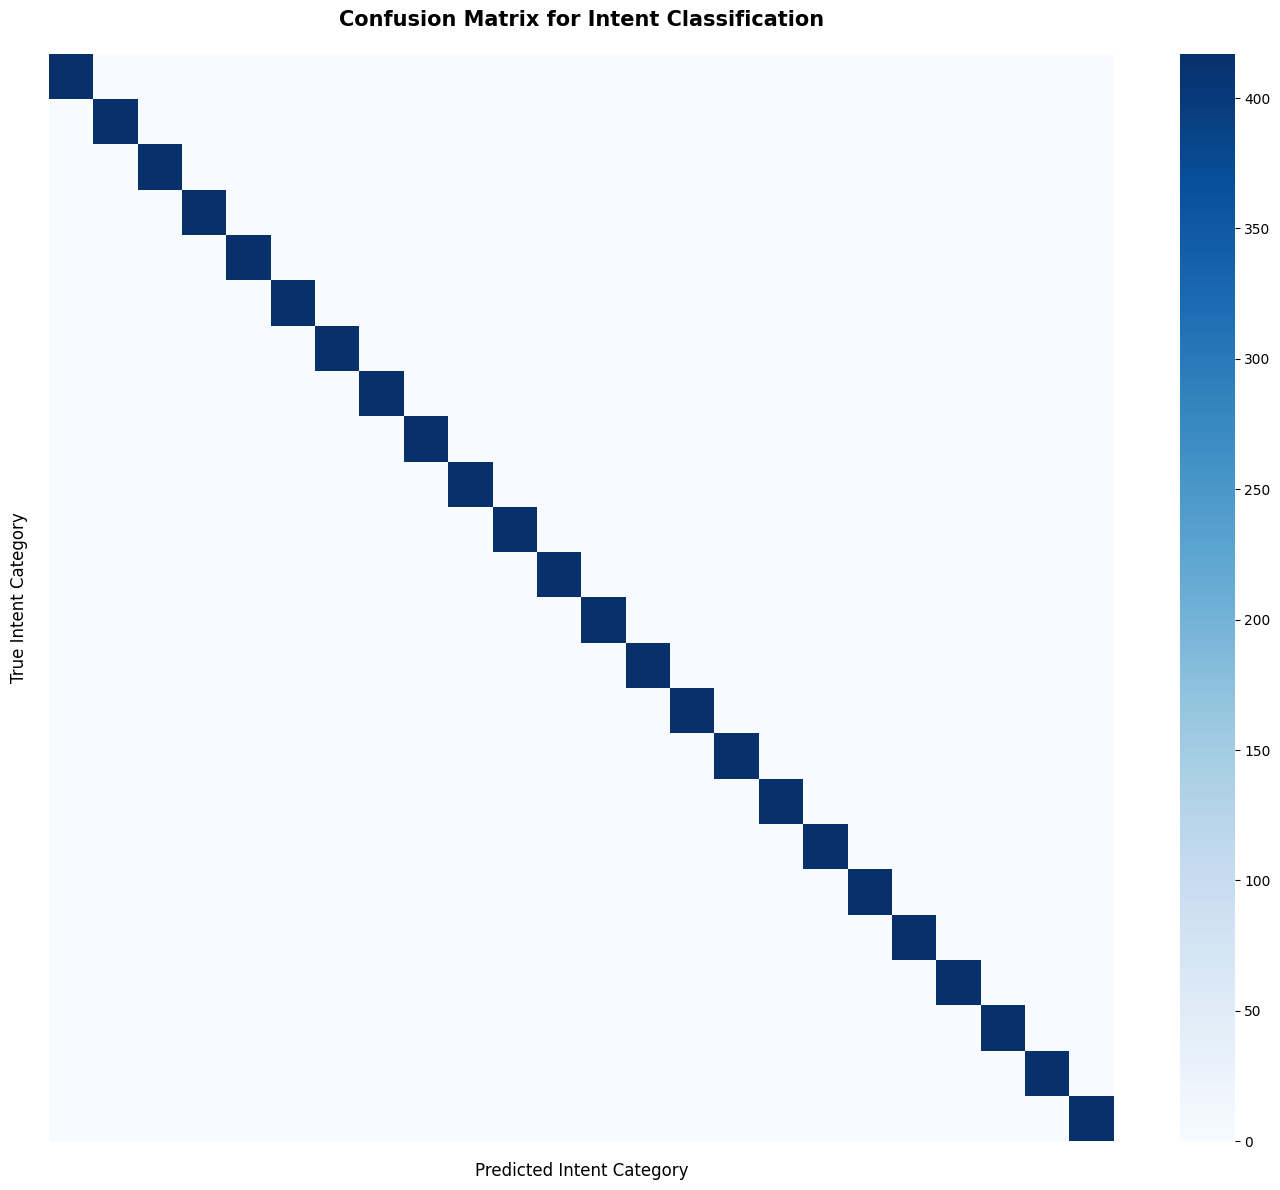

2026-10-04 17:30:42,340 - INFO - Confusion matrix visualization complete.


In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix for Intent Classification", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Predicted Intent Category", fontsize=12, labelpad=15)
plt.ylabel("True Intent Category", fontsize=12, labelpad=15)
plt.tight_layout()
plt.show()

logger.info("Confusion matrix visualization complete.")

--- 
### 10. Production Artifact Serialization
To deploy this model as a microservice (e.g., via FastAPI), we serialize all required data transformation pipelines (vectorizer, label encoder) alongside the trained classifier.

In [10]:
import joblib

logger.info("Serializing model artifacts for production deployment...")

joblib.dump(vectorizer, Config.MODELS_DIR / "tfidf_vectorizer.joblib")
joblib.dump(clf, Config.MODELS_DIR / "intent_classifier.joblib")
joblib.dump(label_encoder, Config.MODELS_DIR / "label_encoder.joblib")

logger.info(f"Successfully exported pipeline artifacts to: {Config.MODELS_DIR.resolve()}")

2026-10-04 17:30:42,346 - INFO - Serializing model artifacts for production deployment...


2026-10-04 17:30:42,353 - INFO - Successfully exported pipeline artifacts to: C:\Users\ramuv\NLP-cornerstone\models
